
# Time Series Analysis using Apple Stock Price Dataset

## Internship Project Notebook

**Prepared By:** 2nd Year BTech AIML Student  
**Domain:** Data Science & Time Series Analysis  
**Dataset Used:** Apple Stock Price Dataset

---

## Introduction

Time series analysis is one of the most important techniques used in financial analytics and stock market prediction.

In this project, Apple stock price data is analyzed to understand how stock prices change over time. The notebook focuses on identifying trends, seasonality patterns, stock volatility, and generating short-term forecasts using beginner-friendly methods.

The project is designed as an internship-level implementation using Python libraries such as Pandas, NumPy, Matplotlib, Seaborn, Statsmodels, and Scikit-learn.



# Project Objective

The main objectives of this project are:

- Analyze historical Apple stock prices
- Perform trend analysis using line plots and rolling averages
- Detect seasonal patterns in stock movement
- Apply time series decomposition techniques
- Create simple forecasting models
- Generate business and investment insights from the data


In [11]:

# Install required libraries (Run only if needed)

# !pip install pandas numpy matplotlib seaborn statsmodels scikit-learn openpyxl


In [12]:
!pip install statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



# Import Libraries


In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')



# Load Dataset

The Apple stock dataset contains historical stock market information such as:

- Open Price
- High Price
- Low Price
- Close Price
- Trading Volume
- Date Information

### Important Note
The dataset contains one unnecessary first row, so it is skipped while loading the file.


In [14]:

# Load Apple stock dataset

stock_df = pd.read_csv("apple_5yr_one.csv", skiprows=1)

# Display first 5 rows
stock_df.head()


,Unnamed: 0,AAPL,AAPL.1,AAPL.2,AAPL.3,AAPL.4
0,2020-06-04,78.329315,79.131269,77.955067,78.832363,87560400
1,2020-06-05,80.560219,80.620973,78.550469,78.579630,137250400
2,2020-06-08,81.036537,81.070563,79.544415,80.256454,95654400
3,2020-06-09,83.595505,83.989192,80.684163,80.715756,147712400
4,2020-06-10,85.746208,86.215230,84.105842,84.545702,166651600



# Dataset Information

This section helps us understand:
- Shape of dataset
- Available columns
- Data types
- Missing values
- Statistical summary


In [15]:

print("Dataset Shape:", stock_df.shape)

print("\nAvailable Columns:")
print(stock_df.columns.tolist())

print("\nDataset Information:")
stock_df.info()


Dataset Shape: (1255, 6)

Available Columns:
['Unnamed: 0', 'AAPL', 'AAPL.1', 'AAPL.2', 'AAPL.3', 'AAPL.4']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1255 non-null   object 
 1   AAPL        1255 non-null   float64
 2   AAPL.1      1255 non-null   float64
 3   AAPL.2      1255 non-null   float64
 4   AAPL.3      1255 non-null   float64
 5   AAPL.4      1255 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 59.0+ KB


In [16]:

# Checking missing values
stock_df.isnull().sum()


Unnamed: 0    0
AAPL          0
AAPL.1        0
AAPL.2        0
AAPL.3        0
AAPL.4        0
dtype: int64

In [17]:

# Statistical summary
stock_df.describe()


,AAPL,AAPL.1,AAPL.2,AAPL.3,AAPL.4
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,164.321062,166.006163,162.443943,164.160646,8.078038e+07
std,38.179689,38.364282,37.891117,38.094942,4.191317e+07
min,78.329315,79.131269,77.955067,78.579630,2.323470e+07
25%,136.922234,139.392588,134.935222,136.720468,5.239195e+07
50%,162.264175,163.728834,160.141728,161.654384,7.046270e+07
75%,188.222137,189.675969,186.846649,188.102500,9.563880e+07
max,258.396667,259.474086,257.010028,257.568678,3.743368e+08



# Data Cleaning and Preprocessing

Data preprocessing is an important step before performing time series analysis.

In this section:
- Duplicate rows are removed
- Missing values are handled
- Data is prepared for analysis


In [18]:

# Remove duplicate records
stock_df.drop_duplicates(inplace=True)

# Handle missing values
stock_df.fillna(method='ffill', inplace=True)

print("Data cleaning completed successfully.")


Data cleaning completed successfully.



# Date-Time Handling

For time series analysis, converting the date column into datetime format is very important.

The date column is also set as the index for better time-based analysis.


In [19]:
# Display columns first
print("Available Columns:")
print(stock_df.columns.tolist())

# Clean column names
stock_df.columns = stock_df.columns.str.strip()

# Automatically detect date column
date_column = None

for column in stock_df.columns:
    if 'date' in column.lower():
        date_column = column
        break

# If still not found, manually use first column
if date_column is None:
    date_column = stock_df.columns[0]

print("Detected Date Column:", date_column)

# Convert date column to datetime
stock_df[date_column] = pd.to_datetime(
    stock_df[date_column],
    errors='coerce'
)

# Remove invalid dates
stock_df.dropna(subset=[date_column], inplace=True)

# Sort values by date
stock_df.sort_values(by=date_column, inplace=True)

# Set date column as index
stock_df.set_index(date_column, inplace=True)

print("Date conversion completed successfully.")

# Display updated dataframe
stock_df.head()

Available Columns:
['Unnamed: 0', 'AAPL', 'AAPL.1', 'AAPL.2', 'AAPL.3', 'AAPL.4']
Detected Date Column: Unnamed: 0
Date conversion completed successfully.


,AAPL,AAPL.1,AAPL.2,AAPL.3,AAPL.4
Unnamed: 0,,,,,
2020-06-04,78.329315,79.131269,77.955067,78.832363,87560400
2020-06-05,80.560219,80.620973,78.550469,78.579630,137250400
2020-06-08,81.036537,81.070563,79.544415,80.256454,95654400
2020-06-09,83.595505,83.989192,80.684163,80.715756,147712400
2020-06-10,85.746208,86.215230,84.105842,84.545702,166651600


In [20]:

# Display updated dataset
stock_df.head()


,AAPL,AAPL.1,AAPL.2,AAPL.3,AAPL.4
Unnamed: 0,,,,,
2020-06-04,78.329315,79.131269,77.955067,78.832363,87560400
2020-06-05,80.560219,80.620973,78.550469,78.579630,137250400
2020-06-08,81.036537,81.070563,79.544415,80.256454,95654400
2020-06-09,83.595505,83.989192,80.684163,80.715756,147712400
2020-06-10,85.746208,86.215230,84.105842,84.545702,166651600



# Exploratory Data Analysis (EDA)

EDA helps understand:
- Overall stock behavior
- Price fluctuations
- Relationships between numerical variables
- Trading activity over time


In [21]:

# Identify numerical columns

numeric_columns = stock_df.select_dtypes(include=np.number).columns.tolist()

print("Numeric Columns:")
print(numeric_columns)


Numeric Columns:
['AAPL', 'AAPL.1', 'AAPL.2', 'AAPL.3', 'AAPL.4']



# Stock Price Trend Analysis

Trend analysis helps identify whether the stock price is increasing, decreasing, or remaining stable over time.


In [22]:

# Detect closing price column automatically

target_column = None

possible_columns = ['close', 'adj close', 'price']

for col in stock_df.columns:
    if col.lower() in possible_columns:
        target_column = col
        break

# Fallback option
if target_column is None:
    target_column = numeric_columns[0]

print("Selected Target Column:", target_column)


Selected Target Column: AAPL


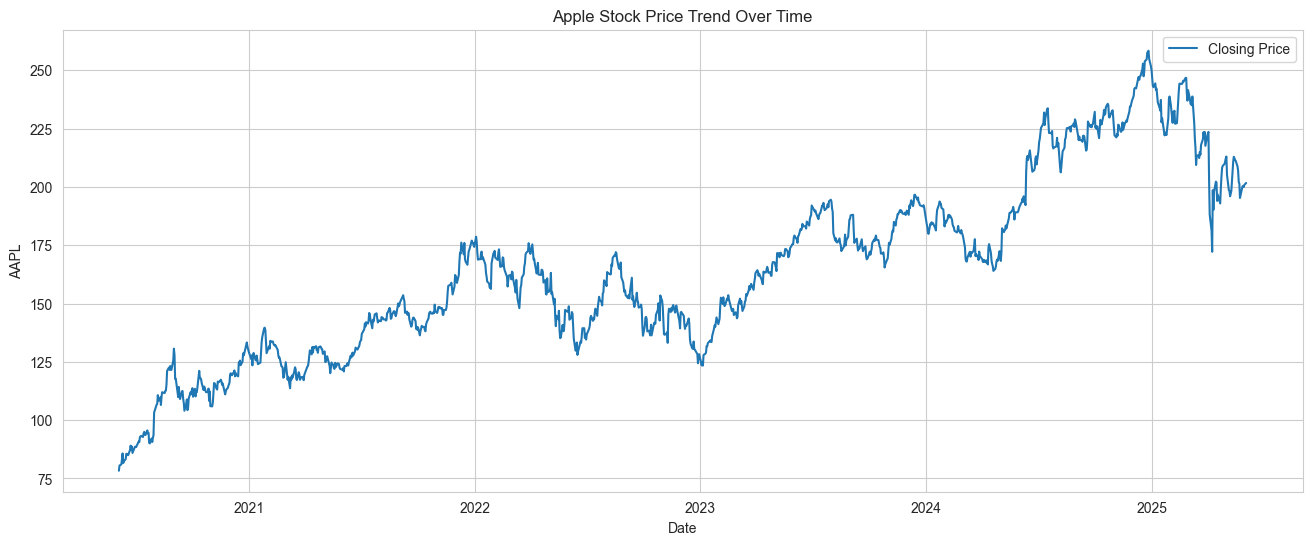

In [23]:

# Plot stock price trend

plt.figure(figsize=(16, 6))

plt.plot(
    stock_df.index,
    stock_df[target_column],
    label='Closing Price'
)

plt.title('Apple Stock Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel(target_column)

plt.legend()
plt.show()



# Rolling Mean and Rolling Standard Deviation

Rolling statistics help smooth short-term fluctuations and show long-term movement patterns.


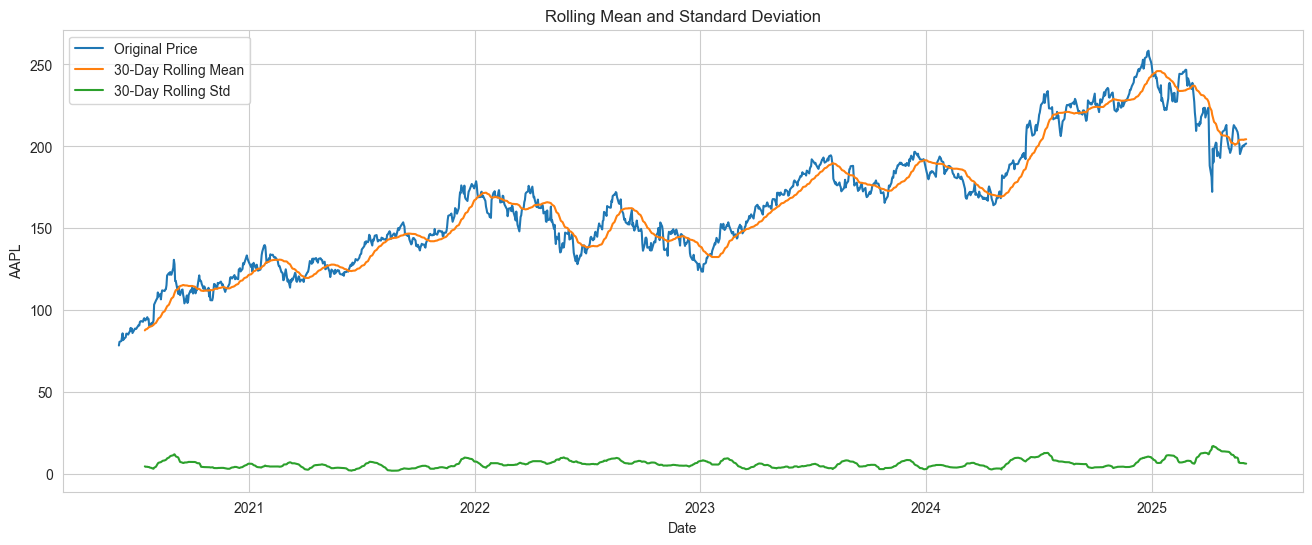

In [24]:

# Calculate rolling statistics

rolling_mean = stock_df[target_column].rolling(window=30).mean()
rolling_std = stock_df[target_column].rolling(window=30).std()

# Plot rolling statistics

plt.figure(figsize=(16, 6))

plt.plot(stock_df[target_column], label='Original Price')
plt.plot(rolling_mean, label='30-Day Rolling Mean')
plt.plot(rolling_std, label='30-Day Rolling Std')

plt.title('Rolling Mean and Standard Deviation')
plt.xlabel('Date')
plt.ylabel(target_column)

plt.legend()
plt.show()



# Seasonality Detection

Seasonality detection helps identify repeating patterns in stock prices over time.


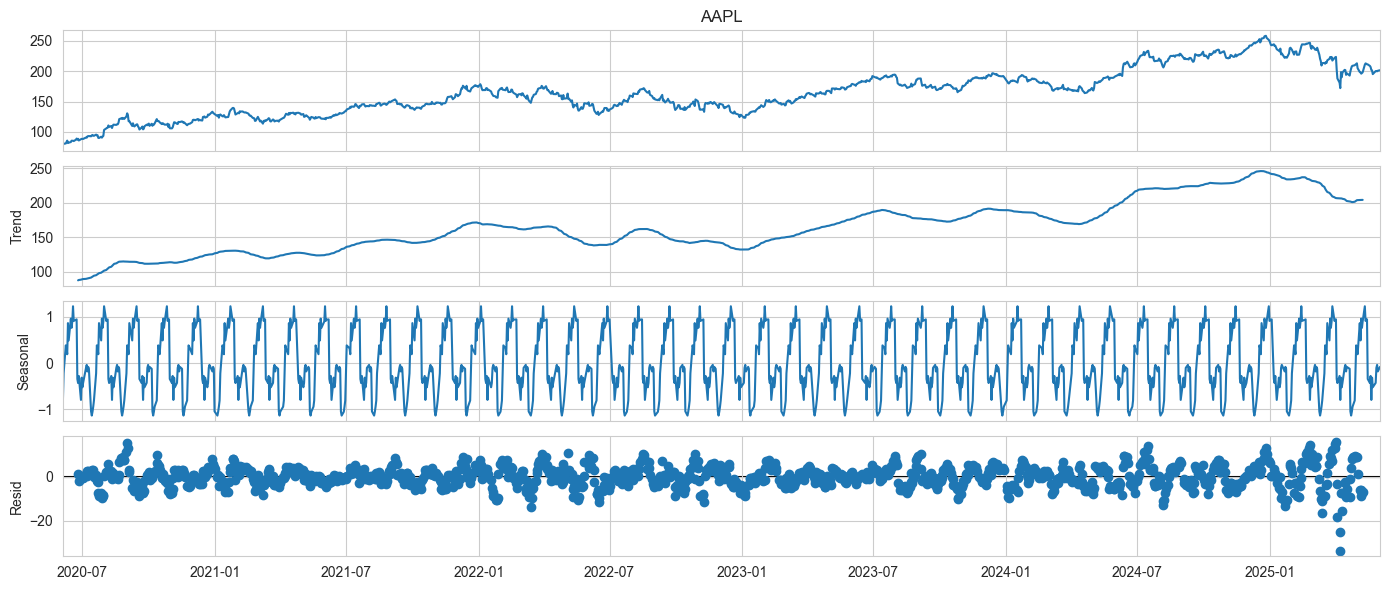

In [25]:

# Time Series Decomposition

decomposition = seasonal_decompose(
    stock_df[target_column],
    model='additive',
    period=30
)

decomposition.plot()
plt.show()



# Correlation Analysis

Correlation analysis helps identify relationships between stock-related numerical variables.


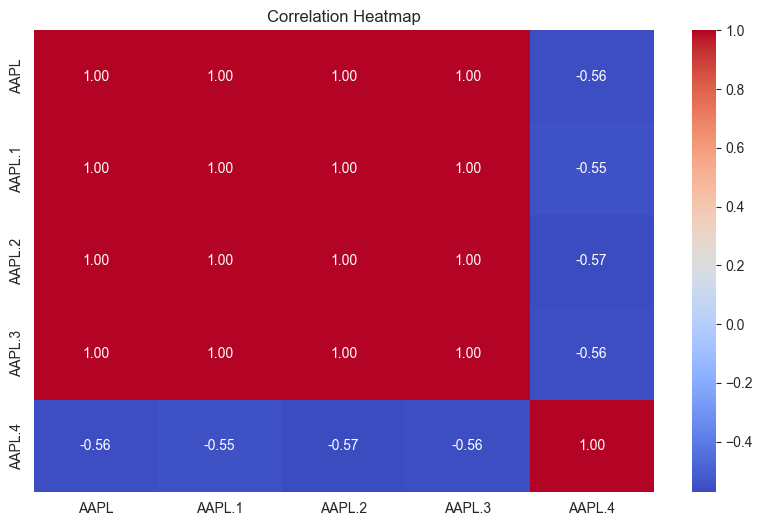

In [26]:

# Correlation heatmap

correlation_matrix = stock_df[numeric_columns].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()



# Forecasting using ARIMA Model

A simple ARIMA model is used to forecast future stock prices.

This method is beginner-friendly and commonly used for time series forecasting projects.


In [27]:

# Build ARIMA forecasting model

time_series_data = stock_df[target_column]

# Create ARIMA model
arima_model = ARIMA(time_series_data, order=(5,1,0))

# Train model
arima_model_fit = arima_model.fit()

# Forecast next 30 days
forecast_steps = 30

forecast_values = arima_model_fit.forecast(steps=forecast_steps)

# Create forecast dates
forecast_dates = pd.date_range(
    start=stock_df.index[-1],
    periods=forecast_steps + 1,
    freq='D'
)[1:]

# Forecast dataframe
forecast_df = pd.DataFrame({
    'Forecast_Date': forecast_dates,
    'Predicted_Stock_Price': forecast_values
})

forecast_df.head()


,Forecast_Date,Predicted_Stock_Price
1255,2025-06-03,201.675550
1256,2025-06-04,201.662404
1257,2025-06-05,201.596533
1258,2025-06-06,201.554953
1259,2025-06-07,201.541558



# Forecast Visualization


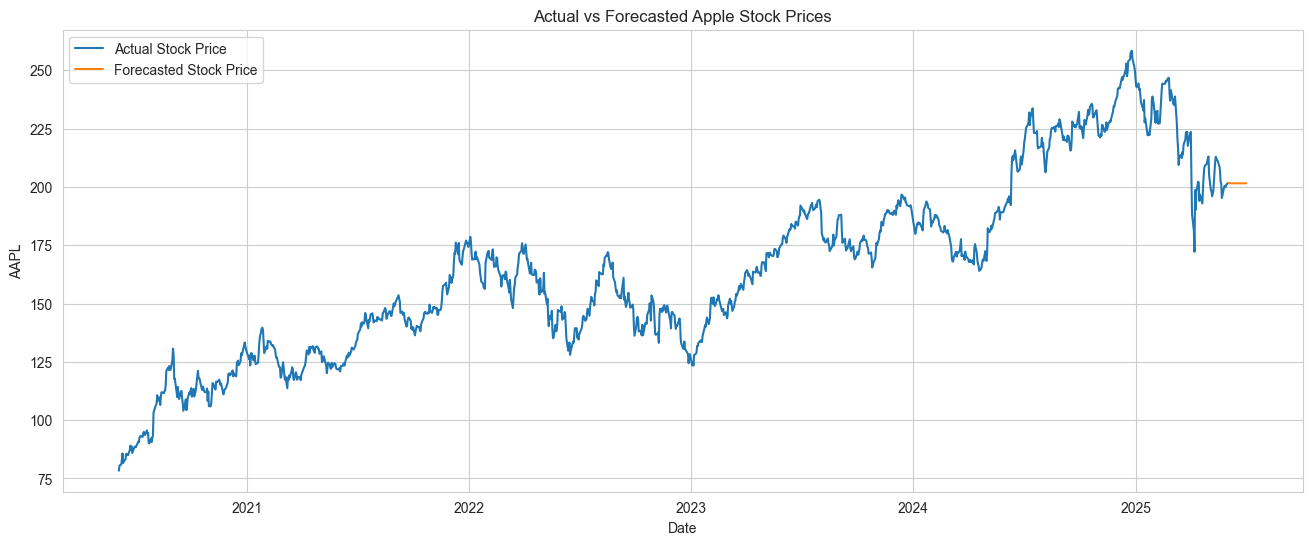

In [28]:

# Plot actual vs forecasted values

plt.figure(figsize=(16, 6))

plt.plot(
    stock_df.index,
    stock_df[target_column],
    label='Actual Stock Price'
)

plt.plot(
    forecast_dates,
    forecast_values,
    label='Forecasted Stock Price'
)

plt.title('Actual vs Forecasted Apple Stock Prices')
plt.xlabel('Date')
plt.ylabel(target_column)

plt.legend()
plt.show()



# Additional Visualization - Distribution Plot


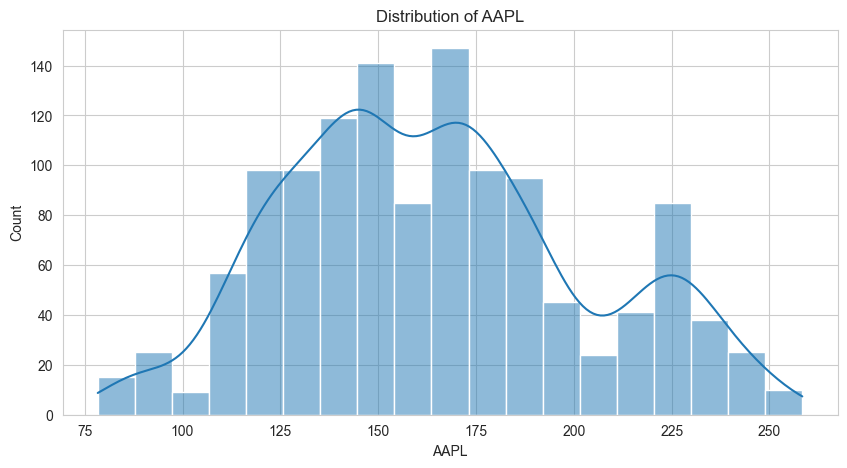

In [29]:

# Distribution plot

plt.figure(figsize=(10, 5))

sns.histplot(stock_df[target_column], kde=True)

plt.title(f'Distribution of {target_column}')
plt.xlabel(target_column)

plt.show()



# Business Insights

Based on the analysis performed on the Apple stock dataset, the following insights were observed:

### Key Observations
- Apple stock prices show an overall long-term growth trend.
- Some periods show high volatility, indicating rapid price fluctuations.
- Rolling averages smooth out daily fluctuations and help visualize the broader trend.
- Seasonal decomposition highlights trend, seasonal, and residual components separately.
- Most stock-related numerical features are highly correlated with each other.

### Forecast Insights
- The ARIMA model predicts future stock movement based on past trends.
- Forecasted values indicate expected short-term price continuation patterns.
- Forecasting can help investors understand possible future behavior of the stock.

### Investment Perspective
- Strong upward trends may indicate investor confidence in Apple stock.
- High volatility periods may represent uncertain market conditions.
- Time series analysis can support better financial decision-making.



# Conclusion

In this project, time series analysis techniques were successfully applied to the Apple stock price dataset.

The notebook covered:
- Data preprocessing
- Date-time handling
- Trend analysis
- Rolling statistics
- Seasonality detection
- Time series decomposition
- Correlation analysis
- Forecasting using ARIMA

Overall, the project provided useful insights into Apple stock market behavior and demonstrated practical implementation of time series analysis techniques using Python.



# Final Thank You Note

Thank you for reviewing this internship project notebook.

This notebook was created as part of a Data Science Internship project on Time Series Analysis using Apple Stock Price Data.

---

### End of Notebook
